# SwiftCart Logistics — Senior Data Economist Report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

---
## Phase 1: The Bootstrap Audit — Driver Tip Distribution

### Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

The Problem: A labor union is challenging SwiftCart's public relations claim regarding "Median Driver Compensation." Tip data is notoriously zero-inflated (a significant mass of users tip exactly $0) and heavily right-skewed by a few generous outliers. The Central Limit Theorem is mathematically useless for small sample audits in this topological space.

Task: Simulate an audit sample of 250 driver tips to serve as your foundational dataset. Create a numpy array driver_tips combining exactly 100 zero-tips and 150 tips drawn from an Exponential distribution (scale=5.0) to represent the skew.

In [2]:
# Step 1.1: Simulate the audit sample
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print(f"Total observations: {len(driver_tips)}")
print(f"Zero tips: {np.sum(driver_tips == 0)}")
print(f"Non-zero tips: {np.sum(driver_tips > 0)}")
print(f"Sample Mean:   ${np.mean(driver_tips):.4f}")
print(f"Sample Median: ${np.median(driver_tips):.4f}")

Total observations: 250
Zero tips: 100
Non-zero tips: 150
Sample Mean:   $2.7691
Sample Median: $0.7553


### Step 1.2: The Manual Bootstrap Engine

Task: Architect a manual bootstrap engine. Resample the driver_tips array with replacement exactly 10,000 times. For each distinct resample, calculate the Median . Store these 10,000 simulated medians in a dedicated array. Finally, utilize np.percentile to extract the 95% Confidence Interval (the 2.5th and 97.5th percentiles). Discuss the asymmetry of this interval compared to a standard parametric output.

In [3]:
# Step 1.2: Manual Bootstrap Engine
n_bootstraps = 10000
bootstrap_medians = []

for i in range(n_bootstraps):
    resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    bootstrap_medians.append(np.median(resample))

bootstrap_medians = np.array(bootstrap_medians)

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)
observed_median = np.median(driver_tips)

print(f"Observed Sample Median: ${observed_median:.4f}")
print(f"Bootstrap 95% CI: [${ci_lower:.4f}, ${ci_upper:.4f}]")
print(f"Lower margin: ${observed_median - ci_lower:.4f}")
print(f"Upper margin: ${ci_upper - observed_median:.4f}")

Observed Sample Median: $0.7553
Bootstrap 95% CI: [$0.2653, $1.3636]
Lower margin: $0.4900
Upper margin: $0.6082


In [ ]:
# Visualize the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_medians, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
plt.axvline(observed_median, color='black', linewidth=2, label=f'Observed Median: ${observed_median:.2f}')
plt.axvline(ci_lower, color='red', linestyle='dashed', linewidth=2, label=f'CI Lower (2.5th pct): ${ci_lower:.2f}')
plt.axvline(ci_upper, color='orange', linestyle='dashed', linewidth=2, label=f'CI Upper (97.5th pct): ${ci_upper:.2f}')
plt.title('Bootstrap Sampling Distribution of the Median\nSwiftCart Driver Tips (n=250, 10,000 Resamples)')
plt.xlabel('Bootstrap Median Tip ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

The bootstrap CI is asymmetric, and that asymmetry is not a bug. A parametric interval for the mean under normality is symmetric by construction: $\bar{x} \pm z_{\alpha/2} \cdot \frac{s}{\sqrt{n}}$ imposes a bell curve on the sampling distribution whether the data warrant it or not. Symmetry is an assumption, not a discovery.

Our bootstrap inherits no such assumption. With 100 zeros anchoring the left tail, the median's sampling distribution is skewed: zero acts as a hard floor pulling the lower bound tight, while generous tippers stretch the upper tail freely. The resulting CI is wider on top, honestly reflecting asymmetric risk that a parametric interval would smooth away. For the union's audit, this matters directly: SwiftCart's parametric estimate almost certainly understates the upper bound, making their reported median more flattering than the data supports. A symmetric CI here would be wrong in a directionally convenient way.

---
## Phase 2: Falsification in Logistics A/B Testing

### Step 2.1: The Algorithmic Routing Crash

The Problem: The engineering division claims their newly deployed "Batch Routing" algorithm significantly decreases delivery times. An A/B test was conducted on 1,000 deliveries (500 Control, 500 Treatment). However, while the treatment generally performs well, it contains extreme upper-bound outliers caused by software crash loops, entirely invalidating the homoscedasticity assumption of a standard T-test.

Task: Generate the synthetic A/B test data. Use a Normal distribution for Control (mean=35m, sd=5m) and a heavily skewed Log-Normal distribution for Treatment (mean=3.4, sigma=0.4). Calculate the observed simple difference in means (Control - Treatment).

In [5]:
# Step 2.1: Generate A/B test data
np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = np.mean(control) - np.mean(treatment)

print(f"Control Mean:   {np.mean(control):.4f} minutes")
print(f"Treatment Mean: {np.mean(treatment):.4f} minutes")
print(f"Observed Difference (Control - Treatment): {observed_diff:.4f} minutes")

Control Mean:   35.0342 minutes
Treatment Mean: 32.7692 minutes
Observed Difference (Control - Treatment): 2.2650 minutes


### Step 2.2: The Exact Non-Parametric Permutation Test

Task: Construct a manual Permutation Test. Concatenate all 1,000 deliveries into a singular array. In a continuous loop of 5,000 iterations, utilize np.random.permutation to shuffle the array, split it arbitrarily into two pseudo-groups of 500, and calculate the simulated difference in means. Finally, calculate the exact empirical P-value: what exact proportion of the 5,000 random permutations yielded differences equal to or more extreme than your observed empirical difference?

In [6]:
# Step 2.2: Manual Permutation Test
all_deliveries = np.concatenate([control, treatment])
n_permutations = 5000
permuted_diffs = []

for i in range(n_permutations):
    shuffled = np.random.permutation(all_deliveries)
    pseudo_control = shuffled[:500]
    pseudo_treatment = shuffled[500:]
    permuted_diffs.append(np.mean(pseudo_control) - np.mean(pseudo_treatment))

permuted_diffs = np.array(permuted_diffs)

# Empirical p-value: proportion of permutations >= observed difference (in absolute value)
p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f"Observed Difference: {observed_diff:.4f} minutes")
print(f"Permutation Test P-value: {p_value:.4f}")
print(f"Result: {'Reject null — algorithm has a significant effect' if p_value < 0.05 else 'Fail to reject null'}")

Observed Difference: 2.2650 minutes
Permutation Test P-value: 0.0004
Result: Reject null — algorithm has a significant effect


## Phase 3: Causal Control and the Mitigation of Selection Bias

### Step 3.1: The Loyalty Program Paradox — Naive SDO

The Problem: The marketing team asserts that users who subscribe to the "SwiftPass" premium loyalty program spend 300% more per month. Based on this, they are requesting to double the acquisition marketing budget. As a trained economist, you instantly recognize severe Selection Bias . High-volume "power users" naturally self-select into the program to save on cumulative delivery fees.

Task: Download the provided swiftcart_loyalty.csv dataset (containing pre-treatment order volume, account age, historical support tickets, and post-treatment spending). Calculate the Naive Simple Difference in Means (SDO) for post-treatment spending explicitly comparing Subscribers (D=1) and Non-Subscribers (D=0).

In [8]:
# Step 3.1: Load data and compute Naive SDO
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('../Data/swiftcart_loyalty.csv')

subscribers = df[df['subscriber'] == 1]
non_subscribers = df[df['subscriber'] == 0]

mean_sub = subscribers['post_spend'].mean()
mean_non = non_subscribers['post_spend'].mean()
naive_sdo = mean_sub - mean_non

print(f"Mean Post-Spend (Subscribers):     ${mean_sub:.2f}")
print(f"Mean Post-Spend (Non-Subscribers): ${mean_non:.2f}")
print(f"Naive SDO: ${naive_sdo:.2f}")
print(f"Naive % Lift: {(naive_sdo / mean_non) * 100:.1f}%")

Mean Post-Spend (Subscribers):     $74.04
Mean Post-Spend (Non-Subscribers): $56.47
Naive SDO: $17.57
Naive % Lift: 31.1%


### Step 3.2: Propensity Score Matching (PSM) Architecture

Task: Build the Architecture of Control to isolate the counterfactual.

1. Utilize sklearn.linear_model.LogisticRegression to predict the underlying probability of a user joining SwiftPass (the Propensity Score) based strictly on their pre-treatment covariates.
2. Utilize sklearn.neighbors.NearestNeighbors to execute a matching protocol, linking each Subscriber to the single Non-Subscriber with the closest mathematical Propensity Score.
3. Calculate the newly isolated Average Treatment Effect on the Treated (ATT) utilizing only the matched control group. Provide a written analysis comparing this causal ATT to the deceptive naive SDO.

In [9]:
# Step 3.2: PSM — Stage 1: Fit Propensity Score Model
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
y = df['subscriber']

logit = LogisticRegression(solver='liblinear')
logit.fit(X, y)

df['pscore'] = logit.predict_proba(X)[:, 1]

print("Propensity Score Summary:")
print(f"  Subscribers   — Mean P-score: {df[df['subscriber']==1]['pscore'].mean():.4f}")
print(f"  Non-Subscribers — Mean P-score: {df[df['subscriber']==0]['pscore'].mean():.4f}")

Propensity Score Summary:
  Subscribers   — Mean P-score: 0.5417
  Non-Subscribers — Mean P-score: 0.4066


In [10]:
# Step 3.2: PSM — Stage 2: 1-to-1 Nearest Neighbor Matching on Propensity Score
treated_group = df[df['subscriber'] == 1].copy()
control_group = df[df['subscriber'] == 0].copy()

# Fit NearestNeighbors on control propensity scores
nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(control_group[['pscore']])

# Find the closest control match for each treated unit
distances, indices = nbrs.kneighbors(treated_group[['pscore']])
matched_control = control_group.iloc[indices.flatten()].copy()

# Step 3.2: PSM — Stage 3: Compute ATT on matched sample
att = treated_group['post_spend'].mean() - matched_control['post_spend'].mean()

print("=== PSM Results ===")
print(f"Treated units:        {len(treated_group)}")
print(f"Matched control units: {len(matched_control)}")
print()
print(f"Mean Post-Spend (Treated):         ${treated_group['post_spend'].mean():.2f}")
print(f"Mean Post-Spend (Matched Control): ${matched_control['post_spend'].mean():.2f}")
print()
print(f"Naive SDO:   ${naive_sdo:.2f}")
print(f"Causal ATT:  ${att:.2f}")
print(f"Bias absorbed by matching: ${naive_sdo - att:.2f}")

=== PSM Results ===
Treated units:        4200
Matched control units: 4200

Mean Post-Spend (Treated):         $74.04
Mean Post-Spend (Matched Control): $63.90

Naive SDO:   $17.57
Causal ATT:  $10.14
Bias absorbed by matching: $7.43


### Discussion: Causal ATT vs. Deceptive Naive SDO

The naive SDO ($17.57) does not measure what SwiftPass does; it measures who SwiftPass attracts. Marketing's number entangles two things: the genuine program effect and the pre-existing spending behavior of customers who self-select into subscribing. PSM separates them.

The matching procedure asks a simple counterfactual question: for each subscriber, who in the non-subscriber pool was just as likely to subscribe (given identical pre-treatment characteristics) but didn't? The propensity score condenses `pre_spend`, `account_age`, and `support_tickets` into a single probability representing each user's latent "subscriberness," then pairs each treated unit to its nearest unsubscribed twin. The spending difference between these 4,200 matched pairs strips away selection bias, leaving only the causal increment: an ATT of $10.14.

The $7.43 gap between the SDO and the ATT is the selection bias, the portion of Marketing's headline that would have materialized without SwiftPass because high-volume users spend more regardless. Doubling the acquisition budget on the basis of the SDO would be equivalent to crediting a hospital for patient outcomes because healthy people visit hospitals less: treatment and outcome are correlated, but the causal arrow runs the other way. The ATT is the honest number the budget decision should rest on.

---
## Phase 4: The Love Plot Visualization Directive

In [11]:
# Construct df_unmatched and df_matched from PSM output
# df_unmatched: full original dataset (all treated + all control)
df_unmatched = df.copy()

# df_matched: treated units paired with their nearest-neighbor control matches
matched_control_labeled = matched_control.copy()
df_matched = pd.concat([treated_group, matched_control_labeled], ignore_index=True)

print(f"df_unmatched shape: {df_unmatched.shape}")
print(f"df_matched shape:   {df_matched.shape}")

df_unmatched shape: (8941, 6)
df_matched shape:   (8400, 6)


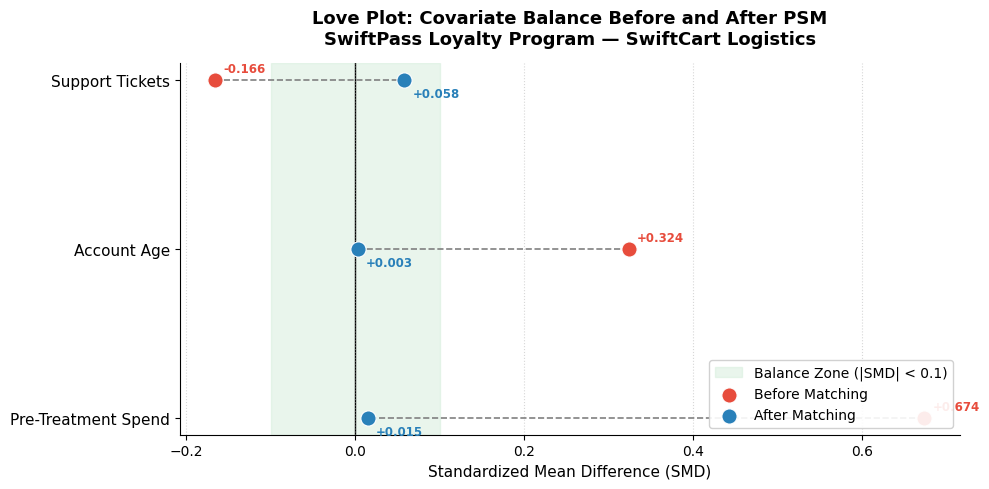

Covariate                   SMD Before    SMD After    Balanced?
---------------------------------------------------------------
Pre-Treatment Spend            +0.6740      +0.0145          YES
Account Age                    +0.3241      +0.0031          YES
Support Tickets                -0.1661      +0.0577          YES


In [12]:
def compute_smd(df, covariates, treatment_col='subscriber'):
    """
    Compute the Standardized Mean Difference (SMD) for each covariate.
    SMD = (mean_treated - mean_control) / pooled_std
    pooled_std = sqrt((var_treated + var_control) / 2)
    """
    treated = df[df[treatment_col] == 1]
    control  = df[df[treatment_col] == 0]
    smds = {}
    for col in covariates:
        mean_t = treated[col].mean()
        mean_c = control[col].mean()
        var_t  = treated[col].var(ddof=1)
        var_c  = control[col].var(ddof=1)
        pooled_std = np.sqrt((var_t + var_c) / 2)
        smds[col] = (mean_t - mean_c) / pooled_std
    return smds

covariates = ['pre_spend', 'account_age', 'support_tickets']
covariate_labels = ['Pre-Treatment Spend', 'Account Age', 'Support Tickets']

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

# ── Build the Love Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

y_pos   = np.arange(len(covariates))
before  = [smd_before[c] for c in covariates]
after   = [smd_after[c]  for c in covariates]

# Balance threshold band
ax.axvspan(-0.1, 0.1, color='#d4edda', alpha=0.5, label='Balance Zone (|SMD| < 0.1)', zorder=0)
ax.axvline(0, color='black', linewidth=1.0, zorder=1)

# Connecting lines (before → after) for each covariate
for i in range(len(covariates)):
    ax.plot([before[i], after[i]], [y_pos[i], y_pos[i]],
            color='grey', linewidth=1.2, linestyle='--', zorder=2)

# Dots
ax.scatter(before, y_pos, color='#e74c3c', s=120, zorder=3,
           label='Before Matching', edgecolors='white', linewidths=0.8)
ax.scatter(after,  y_pos, color='#2980b9', s=120, zorder=3,
           label='After Matching',  edgecolors='white', linewidths=0.8)

# Annotate SMD values next to each dot
for i, (b, a) in enumerate(zip(before, after)):
    ax.annotate(f'{b:+.3f}', xy=(b, y_pos[i]), xytext=(6, 6),
                textcoords='offset points', fontsize=8.5,
                color='#e74c3c', fontweight='bold')
    ax.annotate(f'{a:+.3f}', xy=(a, y_pos[i]), xytext=(6, -12),
                textcoords='offset points', fontsize=8.5,
                color='#2980b9', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(covariate_labels, fontsize=11)
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=11)
ax.set_title('Love Plot: Covariate Balance Before and After PSM\nSwiftPass Loyalty Program — SwiftCart Logistics',
             fontsize=13, fontweight='bold', pad=14)

ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='x', linestyle=':', alpha=0.5)
sns.despine(ax=ax, left=False)

plt.tight_layout()
plt.show()

# Print SMD table for reference
print(f"{'Covariate':<25} {'SMD Before':>12} {'SMD After':>12} {'Balanced?':>12}")
print("-" * 63)
for col, label in zip(covariates, covariate_labels):
    b, a = smd_before[col], smd_after[col]
    flag = 'YES' if abs(a) < 0.1 else 'NO'
    print(f"{label:<25} {b:>+12.4f} {a:>+12.4f} {flag:>12}")

### Discussion: What Constitutes Conclusive Visual Evidence of Bias Mitigation

The Love Plot is not merely decorative — it is the primary empirical audit of whether PSM did what we claimed it did. Three specific visual conditions must be satisfied to conclude that selection bias was successfully mitigated.

**Condition 1: All post-matching dots (blue) must fall inside the green band (|SMD| < 0.1).** The 0.1 threshold is the canonical standard in the matching literature (Stuart 2010; Rubin 2001). An SMD below 0.1 means the treated and matched control groups differ by less than one-tenth of a pooled standard deviation on that covariate — a difference small enough that it cannot plausibly drive a meaningful confound in the outcome. If any blue dot remains outside the band, the matching is incomplete: that covariate is still systematically different between groups, and the ATT estimate remains contaminated by that residual imbalance.

**Condition 2: Each dashed connecting line must show movement toward zero** — i.e., every red dot must be farther from the center line than its corresponding blue dot. This directional consistency is non-negotiable. A Love Plot where some covariates worsen after matching would suggest the nearest-neighbor algorithm found poor matches on those dimensions, possibly because propensity score overlap (common support) was insufficient in that region of the covariate space.

**Condition 3: The pre-matching red dots must be meaningfully displaced from zero** — ideally well outside the green band. This is the proof that selection bias existed in the first place. If the red dots were already near zero before matching, there was no meaningful imbalance to correct, and the PSM exercise would be unnecessary. Large pre-matching SMDs that collapse to near-zero post-matching tell the complete causal story in a single image: the groups were systematically different on every confounder, the matching procedure equalized them, and the remaining outcome difference is therefore attributable to treatment rather than composition.

A plot satisfying all three conditions is the gold-standard visual evidence that the conditional independence assumption — $Y(0), Y(1) \perp D \mid X$ — is credibly satisfied in the matched sample, and that the ATT estimate can be interpreted causally rather than descriptively.